In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("Agri_Data_Cleaned.csv")

target = "NDVI_Season_Mean"

df.head()

,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,District,...,Heat_Stress_Days,Silt,Growth,CN_Ratio,Crop_Name,Organic_Carbon,Transplant,Season,NDVI_Season_Mean,LST_C
0,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Jan To March,8.73,Wheat,33.97,December,Rabi,0.511809,24.144525
1,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Jan To March,8.73,Maize 2,33.97,December,Rabi,0.511809,24.144525
2,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Dec To March,8.73,Boro,33.97,November,Rabi,0.511809,24.144525
3,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Dec To March,8.73,Sweet Potato,33.97,November,Rabi,0.511809,24.144525
4,0.416944,883.021928,0.308177,22.73,656.33,2.481885,16.01,5.86,41.26,Bagerhat,...,54,49.52,No Need To Do,8.73,Mango,33.97,April,Kharif 1,0.267147,28.431973


In [13]:
print(df.shape)

df.info()

(4608, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4608 entries, 0 to 4607
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FPAR                   4608 non-null   float64
 1   Avg_Salinity_Index     4608 non-null   float64
 2   EVI                    4608 non-null   float64
 3   Rain_Temp_Ratio        4608 non-null   float64
 4   Rainfall               4608 non-null   float64
 5   Wind_Mean              4608 non-null   float64
 6   Temp_Min               4608 non-null   float64
 7   Wind_Max               4608 non-null   float64
 8   Temp_Max               4608 non-null   float64
 9   District               4608 non-null   object 
 10  Clay                   4608 non-null   float64
 11  LAI                    4608 non-null   float64
 12  Nitrogen               4608 non-null   float64
 13  Soil_Moisture_mm       4608 non-null   float64
 14  pH                     4608 non-null   float6

In [14]:
df["NDVI_Season_Mean"].describe()

count    4608.000000
mean        0.373672
std         0.107128
min         0.000000
25%         0.305881
50%         0.389344
75%         0.441558
max         0.695371
Name: NDVI_Season_Mean, dtype: float64

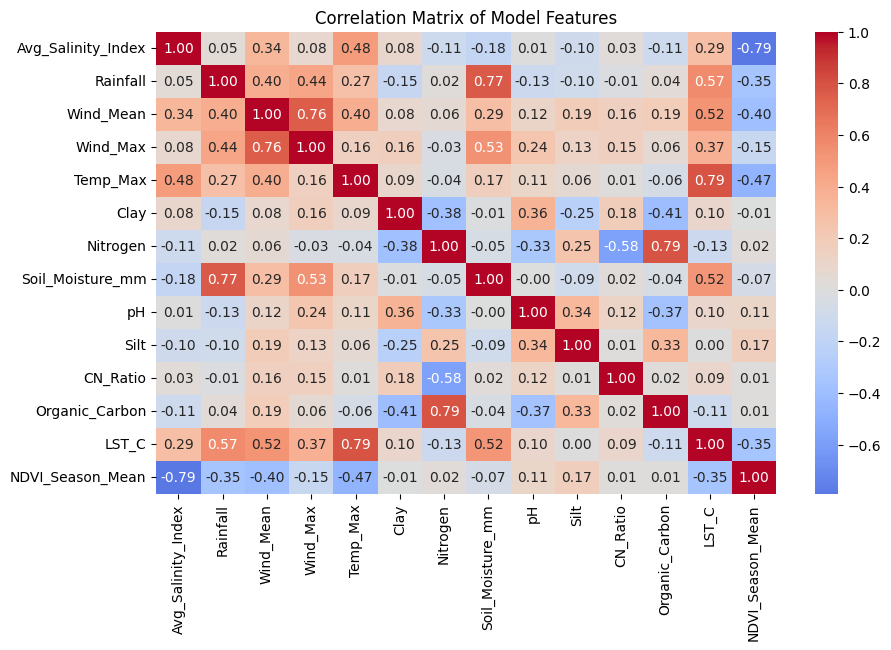

In [15]:
model_cols = [
    "Avg_Salinity_Index", "Rainfall", "Wind_Mean", "Wind_Max",
    "Temp_Max", "Clay", "Nitrogen", "Soil_Moisture_mm",
    "pH", "Silt", "CN_Ratio", "Organic_Carbon", "LST_C",
    "NDVI_Season_Mean"
]

corr = df[model_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Model Features")
plt.show()

Avg_Salinity_Index có mối tương quan âm mạnh nhất với NDVI_Season_Mean (-0.79), cho thấy khi độ mặn tăng thì sức khỏe cây trồng có xu hướng giảm rõ rệt. Ngoài ra, các biến thời tiết như Temp_Max, Wind_Mean, Rainfall và LST_C cũng có tương quan âm với NDVI, cho thấy điều kiện thời tiết khắc nghiệt có thể ảnh hưởng tiêu cực đến cây trồng. Một số biến đất như pH, Nitrogen, Clay có tương quan tuyến tính yếu với NDVI, nhưng vẫn có thể hỗ trợ mô hình khi kết hợp với các biến khác.

C:\Users\Gia Bao\AppData\Local\Temp\ipykernel_26616\862593842.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_ndvi.index, y=season_ndvi.values, palette="viridis")


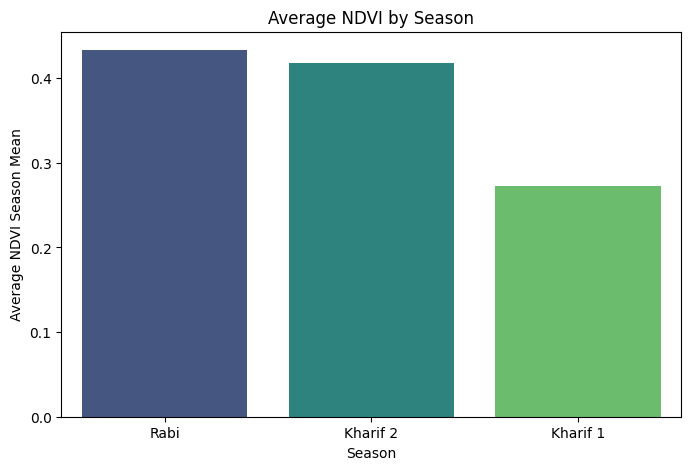

In [16]:
season_ndvi = df.groupby("Season")[target].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=season_ndvi.index, y=season_ndvi.values, palette="viridis")
plt.title("Average NDVI by Season")
plt.xlabel("Season")
plt.ylabel("Average NDVI Season Mean")
plt.show()

best_season = season_ndvi.idxmax()
worst_season = season_ndvi.idxmin()


Chỉ số NDVI trung bình thay đổi theo mùa vụ. Mùa Rabi có NDVI cao nhất, tiếp theo là Kharif 2, cho thấy cây trồng trong hai mùa này có sức khỏe tốt hơn. Ngược lại, Kharif 1 có NDVI thấp nhất, cho thấy điều kiện mùa vụ này có thể kém thuận lợi hơn cho sự phát triển của cây trồng.

C:\Users\Gia Bao\AppData\Local\Temp\ipykernel_26616\2676958783.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crop_ndvi.reset_index(), x="mean_ndvi", y="Crop_Name", palette="mako")


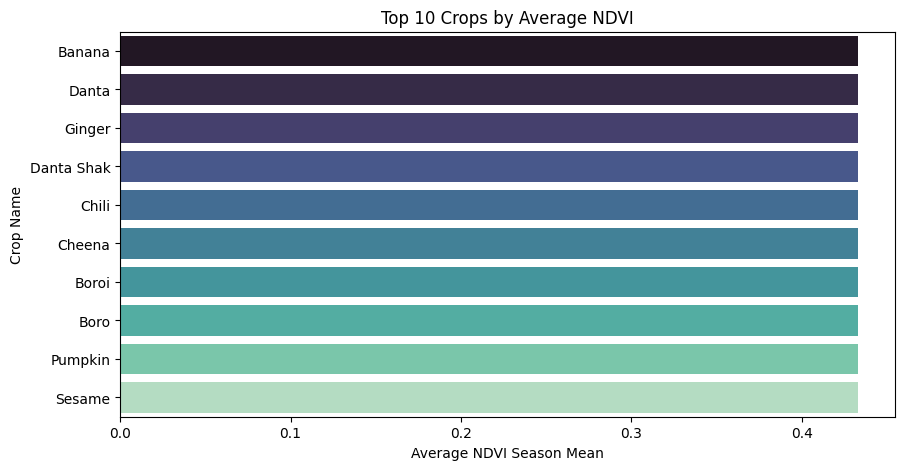

In [17]:
crop_ndvi = (
    df.groupby("Crop_Name")
    .agg(mean_ndvi=(target, "mean"), count=(target, "count"))
    .query("count >= 20")
    .sort_values("mean_ndvi", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=crop_ndvi.reset_index(), x="mean_ndvi", y="Crop_Name", palette="mako")
plt.title("Top 10 Crops by Average NDVI")
plt.xlabel("Average NDVI Season Mean")
plt.ylabel("Crop Name")
plt.show()


10 loại cây có NDVI trung bình cao nhất gồm Banana, Danta, Ginger, Danta Shak, Chili, Cheena, Boroj, Boro, Pumpkin và Sesame. Các giá trị NDVI của nhóm cây này khá gần nhau, đều ở khoảng trên 0.4, cho thấy chúng có tình trạng sinh trưởng tương đối tốt. Banana là cây có NDVI trung bình cao nhất, nên có thể xem là nhóm cây có sức khỏe tốt nhất trong dữ liệu.

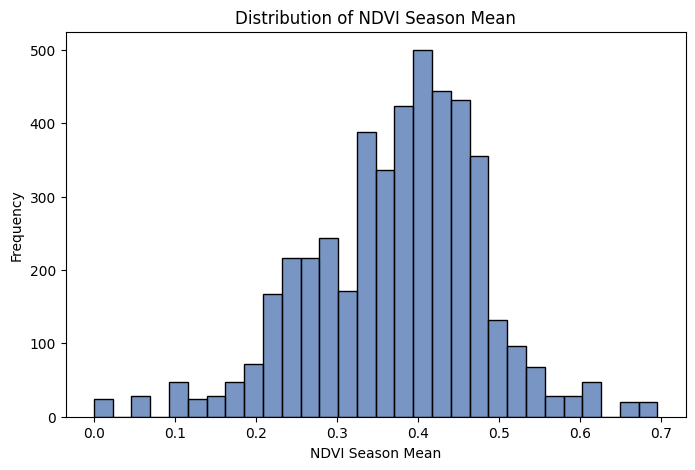

In [18]:
mean_ndvi = df[target].mean()
median_ndvi = df[target].median()

plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=30, color="#4C72B0")
plt.title("Distribution of NDVI Season Mean")
plt.xlabel("NDVI Season Mean")
plt.ylabel("Frequency")
plt.show()


Phân phối của NDVI_Season_Mean tập trung nhiều nhất trong khoảng 0.35 đến 0.45, cho thấy phần lớn cây trồng trong dữ liệu có mức sức khỏe trung bình đến khá tốt. Tuy nhiên vẫn có một số giá trị NDVI rất thấp gần 0 và một số giá trị cao trên 0.6, cho thấy dữ liệu có sự chênh lệch về tình trạng sinh trưởng giữa các mẫu cây trồng.

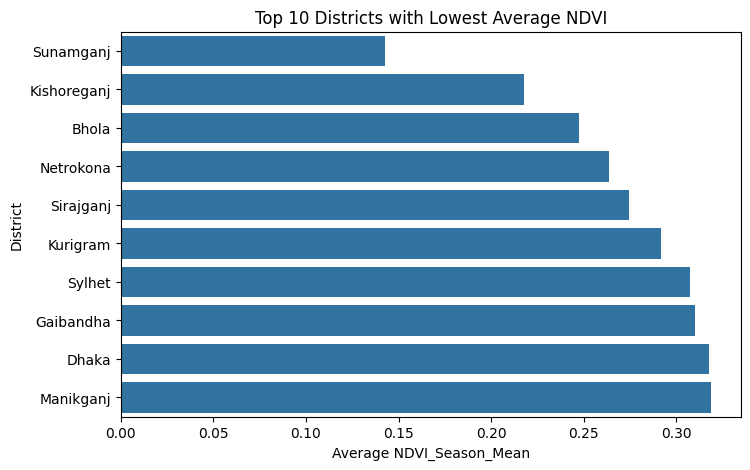

In [19]:
district_ndvi = (
    df.groupby("District")["NDVI_Season_Mean"]
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=district_ndvi.values, y=district_ndvi.index)
plt.title("Top 10 Districts with Lowest Average NDVI")
plt.xlabel("Average NDVI_Season_Mean")
plt.ylabel("District")
plt.show()

Biểu đồ cho thấy Sunamganj là khu vực có NDVI trung bình thấp nhất, phản ánh sức khỏe cây trồng kém hơn so với các district còn lại. Các district như Kishoreganj, Bhola và Netrokona cũng có NDVI thấp, cho thấy đây là những khu vực cần được chú ý khi phân tích và dự báo sức khỏe mùa vụ.

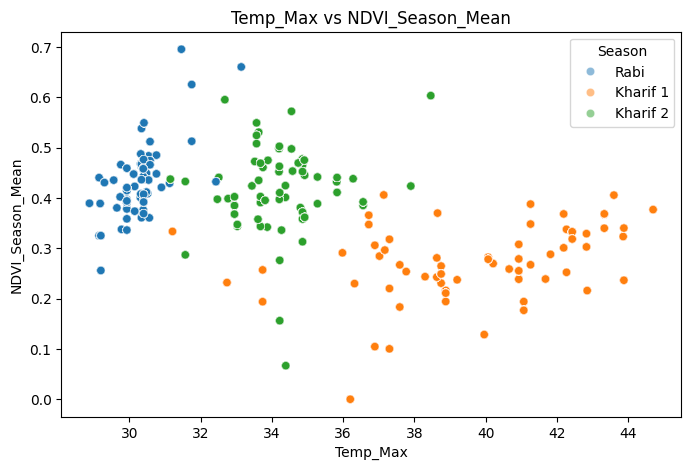

In [20]:
x_col = "Temp_Max"

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x_col, y="NDVI_Season_Mean", alpha=0.5, hue="Season")
plt.title("Temp_Max vs NDVI_Season_Mean")
plt.xlabel("Temp_Max")
plt.ylabel("NDVI_Season_Mean")
plt.show()

Biểu đồ cho thấy Temp_Max có xu hướng tương quan âm với NDVI_Season_Mean: khi nhiệt độ tối đa tăng, NDVI thường giảm. Mùa Kharif 1 có nhiệt độ cao nhất và NDVI thấp hơn rõ rệt so với Rabi và Kharif 2, cho thấy nhiệt độ cao trong mùa vụ có thể ảnh hưởng tiêu cực đến sức khỏe cây trồng.

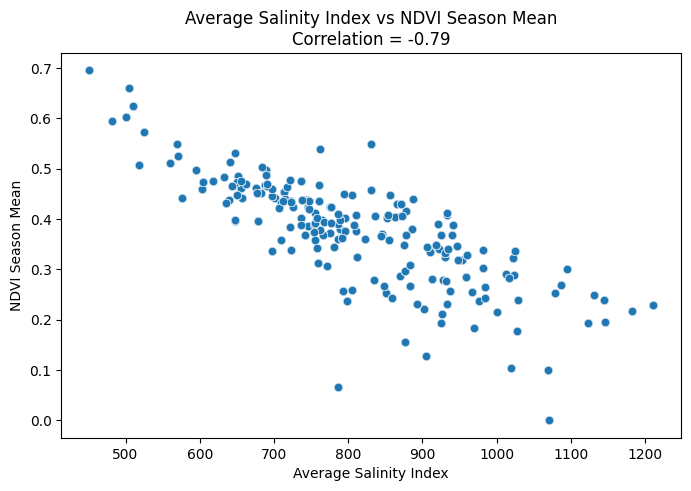

In [21]:
x_col = "Avg_Salinity_Index"
target = "NDVI_Season_Mean"

corr_value = df[[x_col, target]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x=x_col,
    y=target,
    alpha=0.5
)

plt.title(f"Average Salinity Index vs NDVI Season Mean\nCorrelation = {corr_value:.2f}")
plt.xlabel("Average Salinity Index")
plt.ylabel("NDVI Season Mean")
plt.show()

Biểu đồ cho thấy độ mặn trung bình có mối tương quan âm rất mạnh với NDVI, với hệ số tương quan là -0.79. Khi Avg_Salinity_Index tăng, NDVI_Season_Mean có xu hướng giảm rõ rệt. Điều này cho thấy độ mặn cao có thể ảnh hưởng xấu đến sức khỏe cây trồng, làm cây sinh trưởng kém hơn.

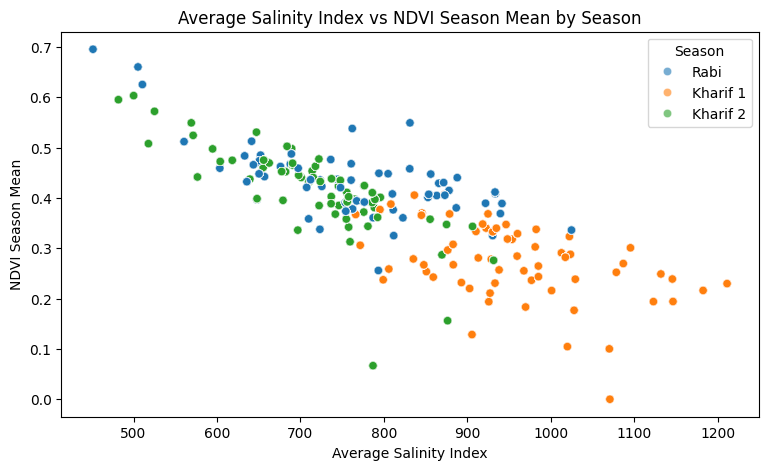

Average NDVI by Season:
Season
Rabi        0.433250
Kharif 2    0.417854
Kharif 1    0.272477
Name: NDVI_Season_Mean, dtype: float64


In [22]:

target = "NDVI_Season_Mean"
x_col = "Avg_Salinity_Index"
hue_col = "Season"

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x=x_col,
    y=target,
    hue=hue_col,
    alpha=0.6
)

plt.title("Average Salinity Index vs NDVI Season Mean by Season")
plt.xlabel("Average Salinity Index")
plt.ylabel("NDVI Season Mean")
plt.legend(title="Season")
plt.show()
season_summary = df.groupby(hue_col)[target].mean().sort_values(ascending=False)

print("Average NDVI by Season:")
print(season_summary)

Biểu đồ cho thấy mối quan hệ âm giữa độ mặn và NDVI vẫn xuất hiện ở từng mùa vụ. Khi Average Salinity Index tăng, NDVI Season Mean có xu hướng giảm. Nhóm Kharif 1 tập trung nhiều ở vùng độ mặn cao và NDVI thấp hơn, trong khi Rabi và Kharif 2 thường có độ mặn thấp hơn và NDVI cao hơn. Điều này cho thấy độ mặn cao có thể là một nguyên nhân làm giảm sức khỏe cây trồng, đặc biệt trong mùa Kharif 1.

In [23]:
fig = px.scatter(
    df,
    x="Soil_Moisture_mm",
    y=target,
    color="Season",
    hover_data=["Crop_Name", "District", "Rainfall", "Heat_Stress_Days"],
    title="Interactive Scatter Plot: Soil Moisture vs NDVI"
)

fig.update_layout(
    xaxis_title="Soil_Moisture_mm",
    yaxis_title="NDVI_Season_Mean",
    legend_title="Season"
)

fig.show()


Biểu đồ cho thấy Soil_Moisture_mm có sự khác biệt rõ giữa các mùa. Rabi thường có độ ẩm đất thấp hơn nhưng NDVI khá cao, Kharif 1 có độ ẩm đất cao hơn nhưng NDVI lại thấp hơn, còn Kharif 2 tập trung ở mức độ ẩm rất cao và NDVI tương đối tốt. Điều này cho thấy độ ẩm đất có ảnh hưởng đến NDVI, nhưng không phải yếu tố duy nhất; mùa vụ và các điều kiện môi trường khác cũng tác động đến sức khỏe cây trồng.